In [1]:
import kagglehub
import shutil
import os

# 1. Download the dataset
path = kagglehub.dataset_download('nikhilroxtomar/brain-tumor-segmentation')
print(f'Data source download complete. Path: {path}')

# 2. Define the destination directory in Colab
destination = '/content/brain-tumor-segmentation'

# 3. Copy the dataset to /content/
# We use copytree to move the entire folder structure
if not os.path.exists(destination):
    shutil.copytree(path, destination)
    print(f'Dataset successfully copied to {destination}')
else:
    print(f'Directory {destination} already exists.')

# List the contents to verify
print("Files in /content/:", os.listdir(destination))

100%|██████████| 312M/312M [00:02<00:00, 133MB/s]

Extracting files...


Data source download complete. Path: /root/.cache/kagglehub/datasets/nikhilroxtomar/brain-tumor-segmentation/versions/1
Dataset successfully copied to /content/brain-tumor-segmentation
Files in /content/: ['masks', 'images']


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Processing train split...


100%|██████████| 2604/2604 [00:14<00:00, 183.75it/s]


Processing val split...


100%|██████████| 460/460 [00:02<00:00, 188.57it/s]



Dataset preparation complete!

Starting YOLO26-seg training on 1 GPU...
Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=256, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/brain-tumor-segmentation/yolodata/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=y

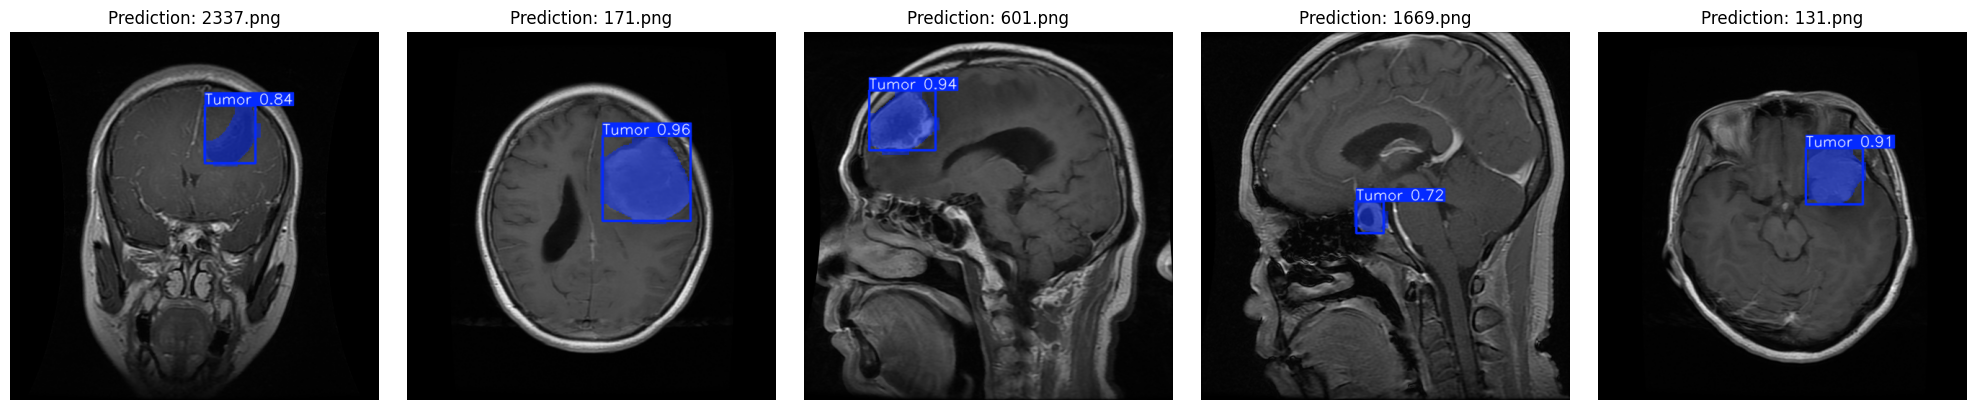

In [2]:
# ==========================================
# 1. SETUP & DEPENDENCIES
# ==========================================
# Install the Ultralytics library which houses the YOLO architectures
!pip install -q ultralytics

import os
import cv2
import shutil
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from ultralytics import YOLO
import matplotlib.pyplot as plt

# ==========================================
# 2. CONFIGURATION & PATHS
# ==========================================
BASE_DIR_1 = '/content/brain-tumor-segmentation'
BASE_DIR_2 = '/content/brain-tumor-segmentation'
BASE_DIR = BASE_DIR_1 if os.path.exists(BASE_DIR_1) else BASE_DIR_2

IMAGE_DIR = os.path.join(BASE_DIR, 'images')
MASK_DIR = os.path.join(BASE_DIR, 'masks')

# Destination paths for the YOLO-formatted dataset
YOLO_DIR = '/content/brain-tumor-segmentation/yolodata'
for split in ['train', 'val']:
    os.makedirs(os.path.join(YOLO_DIR, f'images/{split}'), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DIR, f'labels/{split}'), exist_ok=True)

IMG_SIZE = 256
EPOCHS = 50
# A batch size of 32 is optimal for a single T4 (15GB VRAM) at 256x256 resolution
BATCH_SIZE = 256

# ==========================================
# 3. DATA PREPARATION: MASKS TO YOLO POLYGONS
# ==========================================
def convert_mask_to_yolo_polygons(mask_path, img_w, img_h):
    """
    Reads a binary mask and converts the tumor regions into
    normalized polygon coordinates required by YOLO-seg.
    """
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return []

    # Binarize the mask
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    polygons = []
    for cnt in contours:
        # Filter out tiny artifacts/noise
        if cv2.contourArea(cnt) < 10:
            continue

        cnt = cnt.squeeze()
        if len(cnt.shape) != 2 or len(cnt) < 3:
            continue

        # Normalize coordinates to [0, 1]
        cnt_norm = cnt.astype(float)
        cnt_norm[:, 0] /= img_w
        cnt_norm[:, 1] /= img_h
        cnt_norm = np.clip(cnt_norm, 0.0, 1.0)

        # Flatten into "class_id x1 y1 x2 y2 ..."
        # Class 0 represents 'Tumor'
        coords = " ".join([f"{x:.6f} {y:.6f}" for x, y in cnt_norm])
        polygons.append(f"0 {coords}")

    return polygons

image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')])
mask_files = sorted([f for f in os.listdir(MASK_DIR) if f.endswith('.png')])

# Split into Train and Val (85% Train, 15% Val)
train_img, val_img, train_mask, val_mask = train_test_split(
    image_files, mask_files, test_size=0.15, random_state=42
)

def process_and_copy_split(img_list, mask_list, split_name):
    print(f"Processing {split_name} split...")
    for img_name, mask_name in tqdm(zip(img_list, mask_list), total=len(img_list)):
        img_src = os.path.join(IMAGE_DIR, img_name)
        mask_src = os.path.join(MASK_DIR, mask_name)

        # Determine image dimensions dynamically
        img = cv2.imread(img_src)
        h, w = img.shape[:2]

        # Generate and save polygon labels
        polygons = convert_mask_to_yolo_polygons(mask_src, w, h)
        label_name = img_name.replace('.png', '.txt')
        label_dst = os.path.join(YOLO_DIR, f'labels/{split_name}', label_name)

        with open(label_dst, 'w') as f:
            f.write("\n".join(polygons))

        # Copy the original image to the new YOLO directory
        img_dst = os.path.join(YOLO_DIR, f'images/{split_name}', img_name)
        shutil.copy(img_src, img_dst)

process_and_copy_split(train_img, train_mask, 'train')
process_and_copy_split(val_img, val_mask, 'val')

# Generate dataset.yaml configuration file
yaml_content = f"""
path: {YOLO_DIR}
train: images/train
val: images/val

nc: 1
names: ['Tumor']
"""
with open(os.path.join(YOLO_DIR, 'dataset.yaml'), 'w') as f:
    f.write(yaml_content)

print("\nDataset preparation complete!")

# ==========================================
# 4. TRAINING YOLO26-SEG
# ==========================================
# Initialize the YOLO26 Nano segmentation model
model = YOLO('yolo26n-seg.pt')

print("\nStarting YOLO26-seg training on 1 GPU...")
# Train the model. device=0 restricts computation to the single T4 GPU.
results = model.train(
    data=os.path.join(YOLO_DIR, 'dataset.yaml'),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=0,
    project='brain_tumor_segmentation',
    name='yolo26_run'
)

# ==========================================
# 5. VISUALIZATION ON RANDOM IMAGES
# ==========================================
print("\nVisualizing Random Validation Predictions...")
import random

# Select 5 random validation images
random_val_imgs = random.sample(val_img, 5)

plt.figure(figsize=(20, 4))
for i, img_name in enumerate(random_val_imgs):
    img_path = os.path.join(YOLO_DIR, 'images/val', img_name)

    # Run inference predicting the mask
    res = model.predict(img_path, imgsz=IMG_SIZE, conf=0.25, verbose=False)

    # plot() returns a BGR numpy array with drawn segmentations
    annotated_img = res[0].plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i+1)
    plt.imshow(annotated_img_rgb)
    plt.title(f"Prediction: {img_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()